# 12_first_graph_based_forecasting_baseline.ipynb

## Σκοπός του notebook

Αυτό το notebook αποτελεί το **πρώτο actual graph-based forecasting baseline**
του repository μετά το packaging layer του `NB11`.

Στόχος του είναι να:

- καταναλώσει **μόνο** τα canonical packaged graph artifacts του `NB11`,
- ορίσει ένα **minimal, benchmark-safe, graph-only** forecasting baseline,
- προετοιμάσει καθαρά το training-ready graph dataset interface,
- και να παραμείνει πλήρως ευθυγραμμισμένο με το forecasting-first scope του repo.

## Τι ΔΕΝ κάνει αυτό το notebook στο παρόν scaffold pass

Σε αυτό το πρώτο scaffold pass, το notebook:

- **δεν** ξαναχτίζει raw preprocessing,
- **δεν** ξανακάνει split logic,
- **δεν** ξανακάνει graph packaging,
- **δεν** αλλάζει το `data/processed/baseline_metrics.csv`,
- **δεν** ανοίγει sequence-model scope,
- **δεν** κάνει PHM / fault / prognostics claims.

## Μεθοδολογική θέση

Το `NB10` λειτούργησε ως graph-contract verification stage.
Το `NB11` λειτούργησε ως graph-model input packaging stage.
Το παρόν `NB12` είναι το πρώτο notebook που προχωρά σε
**πραγματικό graph-based forecasting model definition**.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import importlib
import json
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display

# ============================================================
# Fail-fast import policy για PyTorch Geometric
# ============================================================
try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GCNConv
except Exception as exc:
    raise ImportError(
        "Το NB12 απαιτεί εγκατεστημένο το torch_geometric. "
        "Επιβεβαίωσε ότι το environment του repo έχει το σωστό dependency stack."
    ) from exc


# ============================================================
# Reproducibility helpers
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Προσπαθούμε να κάνουμε το run όσο γίνεται πιο deterministic.
# Σημείωση:
# Η απόλυτη determinism μπορεί να έχει performance trade-offs.
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("SEED:", SEED)
print("DEVICE:", DEVICE)
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

SEED: 42
DEVICE: cpu
torch version: 2.10.0+cpu
CUDA available: False


## Logged pitfalls που ενσωματώνουμε στο NB12

Το παρόν notebook γράφεται ώστε να **μην επαναλάβει** γνωστά methodological mistakes
που ήδη καταγράφηκαν στα προηγούμενα στάδια:

1. Δεν γίνεται loose reparsing raw timestamps downstream.
2. Δεν ξαναεισάγεται raw-validation logic μετά το `NB02`.
3. Δεν ξαναχτίζεται graph contract που ήδη σταθεροποιήθηκε στο `NB10`.
4. Δεν ξαναγίνεται packaging logic που ήδη σταθεροποιήθηκε στο `NB11`.
5. Δεν γίνεται mutation του canonical benchmark artifact `baseline_metrics.csv`.
6. Δεν αγνοείται το `observed_mask`.
7. Δεν χρησιμοποιούνται hidden / implicit assumptions για node order ή feature space.
8. Όλα τα core checks είναι **fail-fast** και όχι silent-fallback.

In [2]:
# ============================================================
# Project-root / path helpers
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το repository root ανεβαίνοντας από το current working directory.
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους `data/` και `notebooks/`."
    )


def resolve_under_root(path_like: str | Path, root: Path) -> Path:
    """
    Αν το path είναι σχετικό, το επιλύουμε κάτω από το project root.
    """
    path_obj = Path(path_like)
    return path_obj if path_obj.is_absolute() else (root / path_obj)


ROOT = find_project_root(Path.cwd())

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

try:
    cfg = importlib.import_module("src.config")
except Exception:
    cfg = None


def cfg_get(name: str, default: Any) -> Any:
    """
    Διαβάζει attribute από το src.config μόνο αν υπάρχει.
    """
    if cfg is None:
        return default
    return getattr(cfg, name, default)


# ============================================================
# Canonical constants
# ============================================================
PARK_ID_COLUMN = cfg_get("PARK_ID_COLUMN", "park_id")
TIMESTAMP_COLUMN = cfg_get("TIMESTAMP_COLUMN", "timestamp")
TARGET_COLUMN = cfg_get("TARGET_COLUMN", "Power_Output_Normalized")
BASELINE_COLUMN = cfg_get("BASELINE_COLUMN", "Baseline_Prediction")

NB11_EXPORT_DIR = resolve_under_root(
    cfg_get("NB11_EXPORT_DIR", "data/processed/graph_packaging"),
    ROOT,
)

TRAIN_GRAPH_PACKAGE_PATH = resolve_under_root(
    cfg_get("NB11_TRAIN_GRAPH_DATASET", NB11_EXPORT_DIR / "train_graph_dataset.pt"),
    ROOT,
)
VAL_GRAPH_PACKAGE_PATH = resolve_under_root(
    cfg_get("NB11_VAL_GRAPH_DATASET", NB11_EXPORT_DIR / "val_graph_dataset.pt"),
    ROOT,
)
TEST_GRAPH_PACKAGE_PATH = resolve_under_root(
    cfg_get("NB11_TEST_GRAPH_DATASET", NB11_EXPORT_DIR / "test_graph_dataset.pt"),
    ROOT,
)

NB11_FEATURE_ROLE_MANIFEST_PATH = resolve_under_root(
    cfg_get("NB11_FEATURE_ROLE_MANIFEST", NB11_EXPORT_DIR / "nb11_feature_role_manifest.csv"),
    ROOT,
)
NB11_NODE_FEATURE_MANIFEST_PATH = resolve_under_root(
    cfg_get("NB11_NODE_FEATURE_MANIFEST", NB11_EXPORT_DIR / "nb11_node_feature_manifest.csv"),
    ROOT,
)

BASELINE_METRICS_PATH = resolve_under_root(
    cfg_get("BASELINE_METRICS_PATH", "data/processed/baseline_metrics.csv"),
    ROOT,
)

# ΝΕΟ export namespace για το NB12.
NB12_EXPORT_DIR = resolve_under_root(
    "data/processed/graph_baselines/nb12_first_graph_baseline",
    ROOT,
)
NB12_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("NB11_EXPORT_DIR:", NB11_EXPORT_DIR)
print("NB12_EXPORT_DIR:", NB12_EXPORT_DIR)

ROOT: C:\Users\diony\Desktop\WindPower_DigitalTwin
NB11_EXPORT_DIR: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_packaging
NB12_EXPORT_DIR: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline


## Canonical input contract του NB12

Το `NB12` οφείλει να καταναλώσει **μόνο** τα serialized packaged artifacts του `NB11`.

Στο current implementation υποθέτουμε ότι τα core input artifacts είναι:

- `train_graph_dataset.pt`
- `val_graph_dataset.pt`
- `test_graph_dataset.pt`
- `nb11_feature_role_manifest.csv`
- `nb11_node_feature_manifest.csv`

Το `baseline_metrics.csv` παραμένει μόνο **read-only reference artifact**
για μεταγενέστερη benchmark comparison και δεν χρησιμοποιείται στο current scaffold pass.

In [3]:
# ============================================================
# Load helpers
# ============================================================

def ensure_file_exists(path: Path) -> None:
    """
    Fail-fast έλεγχος ύπαρξης αρχείου.
    """
    if not path.exists():
        raise FileNotFoundError(f"Λείπει required artifact: {path}")


def load_package(path: Path, expected_split_name: str) -> dict[str, Any]:
    """
    Φορτώνει serialized NB11 package και ελέγχει το split_name.
    """
    ensure_file_exists(path)

    package = torch.load(path, map_location="cpu")

    if not isinstance(package, dict):
        raise TypeError(f"Το package στο {path} δεν είναι dict.")

    actual_split_name = package.get("split_name", None)
    if actual_split_name != expected_split_name:
        raise ValueError(
            f"Ασυμφωνία split_name στο {path}. "
            f"Expected={expected_split_name}, found={actual_split_name}"
        )

    return package


# ============================================================
# Load NB11 outputs
# ============================================================
train_package = load_package(TRAIN_GRAPH_PACKAGE_PATH, "train")
val_package = load_package(VAL_GRAPH_PACKAGE_PATH, "val")
test_package = load_package(TEST_GRAPH_PACKAGE_PATH, "test")

ensure_file_exists(NB11_FEATURE_ROLE_MANIFEST_PATH)
ensure_file_exists(NB11_NODE_FEATURE_MANIFEST_PATH)

feature_role_manifest_df = pd.read_csv(NB11_FEATURE_ROLE_MANIFEST_PATH)
node_feature_manifest_df = pd.read_csv(NB11_NODE_FEATURE_MANIFEST_PATH)

print("Loaded packages successfully.")
print("Feature role manifest rows:", len(feature_role_manifest_df))
print("Node feature manifest rows:", len(node_feature_manifest_df))

Loaded packages successfully.
Feature role manifest rows: 48
Node feature manifest rows: 48


## Fail-fast integrity checks πάνω στο NB11 handoff

Πριν φτιάξουμε dataset / model interface, ελέγχουμε ότι το packaging handoff
είναι shape-safe, contract-safe και split-safe.

Κρίσιμο:
το `NB12` **δεν** διορθώνει σιωπηλά broken packages.
Αν κάτι είναι λάθος, αποτυγχάνει ρητά.

In [4]:
# ============================================================
# Required package schema
# ============================================================

REQUIRED_PACKAGE_KEYS = {
    "split_name",
    "node_ids",
    "timestamps",
    "edge_index",
    "edge_attr_km",
    "static_x",
    "dynamic_x",
    "target_y",
    "baseline_reference",
    "observed_mask",
    "static_feature_names",
    "dynamic_feature_names",
    "target_name",
    "baseline_name",
    "n_nodes",
    "n_timestamps",
    "n_static_features",
    "n_dynamic_features",
}

def assert_required_keys(package: dict[str, Any], split_name: str) -> None:
    missing = sorted(REQUIRED_PACKAGE_KEYS - set(package.keys()))
    if missing:
        raise KeyError(f"Το split `{split_name}` λείπει required keys: {missing}")


def assert_package_tensor_shapes(package: dict[str, Any], split_name: str) -> None:
    static_x = package["static_x"]
    dynamic_x = package["dynamic_x"]
    target_y = package["target_y"]
    baseline_reference = package["baseline_reference"]
    observed_mask = package["observed_mask"]
    edge_index = package["edge_index"]
    edge_attr_km = package["edge_attr_km"]

    if static_x.ndim != 2:
        raise ValueError(f"`{split_name}` static_x πρέπει να είναι 2D.")
    if dynamic_x.ndim != 3:
        raise ValueError(f"`{split_name}` dynamic_x πρέπει να είναι 3D [T, N, D].")
    if target_y.ndim != 2:
        raise ValueError(f"`{split_name}` target_y πρέπει να είναι 2D [T, N].")
    if baseline_reference.ndim != 2:
        raise ValueError(f"`{split_name}` baseline_reference πρέπει να είναι 2D [T, N].")
    if observed_mask.ndim != 2:
        raise ValueError(f"`{split_name}` observed_mask πρέπει να είναι 2D [T, N].")
    if edge_index.ndim != 2 or edge_index.shape[0] != 2:
        raise ValueError(f"`{split_name}` edge_index πρέπει να είναι shape [2, E].")
    if edge_attr_km.ndim != 2:
        raise ValueError(f"`{split_name}` edge_attr_km πρέπει να είναι 2D [E, A].")

    # Cross-shape checks
    if tuple(observed_mask.shape) != tuple(target_y.shape):
        raise ValueError(
            f"`{split_name}` observed_mask και target_y δεν έχουν ίδιο shape."
        )

    if tuple(baseline_reference.shape) != tuple(target_y.shape):
        raise ValueError(
            f"`{split_name}` baseline_reference και target_y δεν έχουν ίδιο shape."
        )

    if dynamic_x.shape[0] != target_y.shape[0]:
        raise ValueError(f"`{split_name}` ασυμφωνία T ανάμεσα σε dynamic_x και target_y.")
    if dynamic_x.shape[1] != target_y.shape[1]:
        raise ValueError(f"`{split_name}` ασυμφωνία N ανάμεσα σε dynamic_x και target_y.")

    if static_x.shape[0] != target_y.shape[1]:
        raise ValueError(f"`{split_name}` static_x δεν ταιριάζει στο node dimension.")

    if edge_attr_km.shape[0] != edge_index.shape[1]:
        raise ValueError(f"`{split_name}` edge_attr_km δεν ταιριάζει στο πλήθος edges.")

    if int(observed_mask.sum().item()) == 0:
        raise ValueError(f"`{split_name}` δεν έχει καμία observed node entry.")

    observed_per_timestamp = observed_mask.sum(dim=1)
    if torch.any(observed_per_timestamp == 0):
        raise ValueError(
            f"`{split_name}` περιέχει timestamp χωρίς καμία observed node entry."
        )


def assert_observed_entries_are_not_nan(package: dict[str, Any], split_name: str) -> None:
    observed_mask = package["observed_mask"].cpu()
    target_y = package["target_y"].cpu()
    baseline_reference = package["baseline_reference"].cpu()
    dynamic_x = package["dynamic_x"].cpu()

    # observed target entries
    if torch.isnan(target_y)[observed_mask].any():
        raise ValueError(f"`{split_name}` έχει NaN target_y πάνω σε observed entries.")

    # observed baseline entries
    if torch.isnan(baseline_reference)[observed_mask].any():
        raise ValueError(f"`{split_name}` έχει NaN baseline_reference πάνω σε observed entries.")

    # observed dynamic entries
    if dynamic_x.numel() > 0:
        observed_mask_3d = observed_mask.unsqueeze(-1).expand_as(dynamic_x)
        if torch.isnan(dynamic_x)[observed_mask_3d].any():
            raise ValueError(f"`{split_name}` έχει NaN dynamic_x πάνω σε observed entries.")


for split_name, package in {
    "train": train_package,
    "val": val_package,
    "test": test_package,
}.items():
    assert_required_keys(package, split_name)
    assert_package_tensor_shapes(package, split_name)
    assert_observed_entries_are_not_nan(package, split_name)

# ============================================================
# Cross-split contract checks
# ============================================================

if train_package["node_ids"] != val_package["node_ids"] or train_package["node_ids"] != test_package["node_ids"]:
    raise ValueError("Ασυμφωνία node_ids ordering μεταξύ train / val / test packages.")

if train_package["static_feature_names"] != val_package["static_feature_names"] or train_package["static_feature_names"] != test_package["static_feature_names"]:
    raise ValueError("Ασυμφωνία static_feature_names μεταξύ splits.")

if train_package["dynamic_feature_names"] != val_package["dynamic_feature_names"] or train_package["dynamic_feature_names"] != test_package["dynamic_feature_names"]:
    raise ValueError("Ασυμφωνία dynamic_feature_names μεταξύ splits.")

if not torch.equal(train_package["edge_index"], val_package["edge_index"]) or not torch.equal(train_package["edge_index"], test_package["edge_index"]):
    raise ValueError("Ασυμφωνία edge_index topology μεταξύ splits.")

if not torch.equal(train_package["edge_attr_km"], val_package["edge_attr_km"]) or not torch.equal(train_package["edge_attr_km"], test_package["edge_attr_km"]):
    raise ValueError("Ασυμφωνία edge_attr_km μεταξύ splits.")

print("NB11 handoff integrity checks passed.")

NB11 handoff integrity checks passed.


,split_name,n_timestamps,n_nodes,n_static_features,n_dynamic_features,partial_timestamp_count,full_coverage_timestamp_count,min_observed_nodes_per_timestamp,max_observed_nodes_per_timestamp,mean_observed_nodes_per_timestamp
0,train,7819,256,5,36,6494,1325,244,256,253.579230
1,val,720,256,5,36,593,127,249,256,254.163889
2,test,4295,256,5,36,4096,199,245,256,252.930384


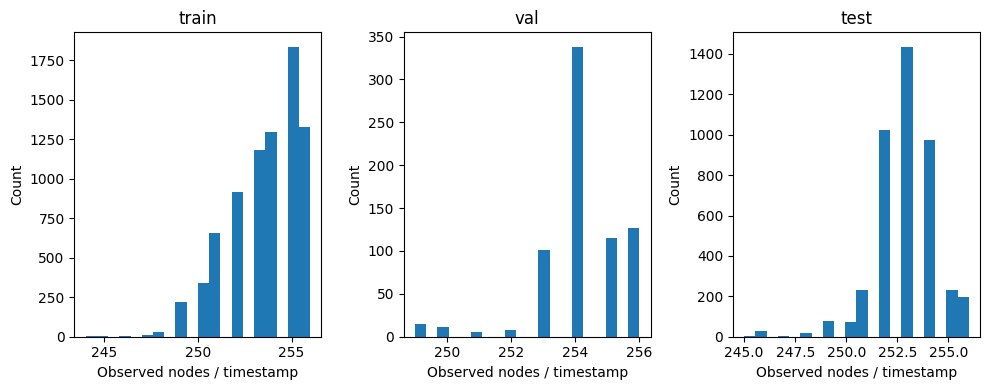

In [5]:
# ============================================================
# Compact package summary
# ============================================================

def summarize_package(package: dict[str, Any]) -> dict[str, Any]:
    observed_per_timestamp = package["observed_mask"].sum(dim=1).cpu().numpy()

    return {
        "split_name": package["split_name"],
        "n_timestamps": int(package["n_timestamps"]),
        "n_nodes": int(package["n_nodes"]),
        "n_static_features": int(package["n_static_features"]),
        "n_dynamic_features": int(package["n_dynamic_features"]),
        "partial_timestamp_count": int(package["partial_timestamp_count"]),
        "full_coverage_timestamp_count": int(package["full_coverage_timestamp_count"]),
        "min_observed_nodes_per_timestamp": int(observed_per_timestamp.min()),
        "max_observed_nodes_per_timestamp": int(observed_per_timestamp.max()),
        "mean_observed_nodes_per_timestamp": float(observed_per_timestamp.mean()),
    }

package_summary_df = pd.DataFrame(
    [
        summarize_package(train_package),
        summarize_package(val_package),
        summarize_package(test_package),
    ]
)

display(package_summary_df)

# ============================================================
# Coverage histograms
# ============================================================
fig = plt.figure(figsize=(10, 4))

for i, package in enumerate([train_package, val_package, test_package], start=1):
    observed_per_timestamp = package["observed_mask"].sum(dim=1).cpu().numpy()

    ax = fig.add_subplot(1, 3, i)
    ax.hist(observed_per_timestamp, bins=20)
    ax.set_title(package["split_name"])
    ax.set_xlabel("Observed nodes / timestamp")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Snapshot-level graph dataset design

Για το πρώτο graph baseline χρησιμοποιούμε την εξής formulation:

- κάθε **timestamp** αντιστοιχεί σε ένα graph snapshot,
- οι **κόμβοι** είναι τα parks,
- οι **ακμές** είναι το canonical `edge_index`,
- το node feature matrix είναι:
  - `static_x`
  - `dynamic_x[t]`
  - `observed_indicator`

Σημαντική απόφαση:
δεν χρησιμοποιούμε ακόμη το `baseline_reference` ως input feature,
ώστε το πρώτο graph baseline να παραμείνει καθαρό και benchmark-safe.

Επίσης:
όπου υπάρχουν unobserved node entries, κάνουμε safe numeric fill μόνο στο input tensor,
αλλά η **loss / metrics λογική** θα στηριχθεί αργότερα αποκλειστικά στο `observed_mask`.

In [6]:
# ============================================================
# Dataset wrapper: one graph per timestamp
# ============================================================

class TemporalGraphSnapshotDataset(torch.utils.data.Dataset):
    """
    Dataset που μετατρέπει ένα packaged split σε λίστα από graph snapshots.

    Κάθε item αντιστοιχεί σε ένα timestamp.
    Το x φτιάχνεται ως concat(static_x, dynamic_x[t], observed_indicator).
    """

    def __init__(
        self,
        package: dict[str, Any],
        include_observed_indicator: bool = True,
        fill_value: float = 0.0,
    ) -> None:
        self.package = package
        self.include_observed_indicator = include_observed_indicator
        self.fill_value = fill_value

        self.timestamps = list(package["timestamps"])
        self.node_ids = list(package["node_ids"])

        self.input_feature_names = (
            list(package["static_feature_names"])
            + list(package["dynamic_feature_names"])
        )

        if self.include_observed_indicator:
            self.input_feature_names = self.input_feature_names + ["observed_indicator"]

        self.n_input_features = len(self.input_feature_names)

    def __len__(self) -> int:
        return int(self.package["n_timestamps"])

    def _build_x(self, t_index: int) -> torch.Tensor:
        """
        Φτιάχνει node feature matrix για ένα timestamp.
        """
        static_x = self.package["static_x"]                         # [N, S]
        dynamic_x_t = self.package["dynamic_x"][t_index]           # [N, D]
        observed_mask_t = self.package["observed_mask"][t_index]   # [N]

        # Safe fill για unobserved entries ή τυχόν NaN entries εκτός observed scope.
        dynamic_x_t = torch.nan_to_num(
            dynamic_x_t,
            nan=self.fill_value,
            posinf=self.fill_value,
            neginf=self.fill_value,
        )

        parts = [static_x, dynamic_x_t]

        if self.include_observed_indicator:
            observed_indicator = observed_mask_t.to(torch.float32).unsqueeze(-1)  # [N, 1]
            parts.append(observed_indicator)

        x = torch.cat(parts, dim=1)

        if x.ndim != 2:
            raise ValueError(f"Expected 2D node feature matrix, found shape={tuple(x.shape)}")

        return x

    def __getitem__(self, index: int) -> Data:
        if not (0 <= index < len(self)):
            raise IndexError(f"Index out of range: {index}")

        x = self._build_x(index)

        data = Data(
            x=x,
            edge_index=self.package["edge_index"],
            y=self.package["target_y"][index],
        )

        # Κρατάμε edge_attr για μελλοντική επέκταση, έστω κι αν η πρώτη GCN δεν το χρησιμοποιεί.
        data.edge_attr = self.package["edge_attr_km"]

        # observed mask για μελλοντική masked loss / masked metrics.
        data.observed_mask = self.package["observed_mask"][index]

        # baseline reference διατηρείται μόνο για downstream inspection / future comparison.
        data.baseline_reference = self.package["baseline_reference"][index]

        # Tensor-only metadata ώστε να είναι DataLoader-safe.
        data.time_index = torch.tensor([index], dtype=torch.long)
        data.num_nodes = int(self.package["n_nodes"])

        return data


train_dataset = TemporalGraphSnapshotDataset(train_package)
val_dataset = TemporalGraphSnapshotDataset(val_package)
test_dataset = TemporalGraphSnapshotDataset(test_package)

print("Datasets created successfully.")
print("Train snapshots:", len(train_dataset))
print("Val snapshots  :", len(val_dataset))
print("Test snapshots :", len(test_dataset))
print("Input feature dim:", train_dataset.n_input_features)

Datasets created successfully.
Train snapshots: 7819
Val snapshots  : 720
Test snapshots : 4295
Input feature dim: 42


In [7]:
# ============================================================
# Sample inspection
# ============================================================

sample = train_dataset[0]

print(sample)
print("-" * 80)
print("sample.x shape           :", tuple(sample.x.shape))
print("sample.y shape           :", tuple(sample.y.shape))
print("sample.edge_index shape  :", tuple(sample.edge_index.shape))
print("sample.edge_attr shape   :", tuple(sample.edge_attr.shape))
print("sample.observed_mask shape:", tuple(sample.observed_mask.shape))
print("sample.num_nodes         :", sample.num_nodes)
print("first train timestamp    :", train_dataset.timestamps[0])

assert sample.x.shape[0] == train_package["n_nodes"]
assert sample.y.shape[0] == train_package["n_nodes"]
assert sample.observed_mask.shape[0] == train_package["n_nodes"]
assert sample.x.shape[1] == train_dataset.n_input_features

preview_feature_df = pd.DataFrame(
    {
        "input_feature_name": train_dataset.input_feature_names
    }
)

display(preview_feature_df.head(20))

Data(x=[256, 42], edge_index=[2, 1068], y=[256], edge_attr=[1068, 1], observed_mask=[256], baseline_reference=[256], time_index=[1], num_nodes=256)
--------------------------------------------------------------------------------
sample.x shape           : (256, 42)
sample.y shape           : (256,)
sample.edge_index shape  : (2, 1068)
sample.edge_attr shape   : (1068, 1)
sample.observed_mask shape: (256,)
sample.num_nodes         : 256
first train timestamp    : 2018-12-08 06:00:00


,input_feature_name
0,lat
1,long
2,hub_height_m
3,rotor_diameter_m
4,nominal_power_kW
5,nwp_fcst_horiz_hours
6,T_HAG_2_M
7,RELHUM_HAG_2_M
8,PS_SFC_0_M
9,U_GVL_58_HL


## DataLoader policy

Για το πρώτο baseline κρατάμε μικρά και καθαρά mini-batches από graph snapshots.

- `shuffle=True` μόνο στο train
- `shuffle=False` σε validation / test
- δεν χρησιμοποιούμε ακόμη neighbor sampling
- δεν χρησιμοποιούμε ακόμη temporal windows
- δεν κάνουμε ακόμη graph sequence batching

Αυτό κρατά το πρώτο `NB12` όσο γίνεται πιο καθαρό:
**spatial graph baseline first, temporal complexity later**

In [8]:
# ============================================================
# DataLoaders
# ============================================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("BATCH_SIZE:", BATCH_SIZE)
print("Train loader batches:", len(train_loader))
print("Val loader batches  :", len(val_loader))
print("Test loader batches :", len(test_loader))

BATCH_SIZE: 16
Train loader batches: 489
Val loader batches  : 45
Test loader batches : 269


## Επιλογή minimal graph model

Για το πρώτο actual graph baseline επιλέγουμε **2-layer GCN node regressor**.

Γιατί όχι GraphSAGE στο πρώτο pass;

- το `GCN` είναι πιο canonical και πιο minimal,
- έχει πιο καθαρό official pattern,
- είναι αρκετό για να μετρήσουμε την πρώτη spatial graph contribution,
- αποφεύγουμε επιπλέον aggregation hyperparameters στο πρώτο benchmark-safe pass.

Το output είναι **μία scalar πρόβλεψη ανά node**.

In [9]:
# ============================================================
# Minimal GCN node regressor
# ============================================================

class GCNNodeRegressor(nn.Module):
    """
    Minimal node-level regression GCN για το πρώτο graph-based forecasting pass.
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 64,
        dropout: float = 0.20,
    ) -> None:
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.head = nn.Linear(hidden_channels, 1)

        self.dropout = float(dropout)

    def forward(self, data: Data) -> torch.Tensor:
        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        out = self.head(x).squeeze(-1)

        return out


model = GCNNodeRegressor(
    in_channels=train_dataset.n_input_features,
    hidden_channels=64,
    dropout=0.20,
).to(DEVICE)

print(model)

GCNNodeRegressor(
  (conv1): GCNConv(42, 64)
  (conv2): GCNConv(64, 64)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


## Mask-aware loss utilities

Το `NB11` μάς έδωσε `observed_mask`.
Το `NB12` οφείλει να το χρησιμοποιήσει.

Στο scaffold pass ορίζουμε από τώρα τις core masked utilities:

- masked MSE loss
- masked MAE
- masked RMSE
- masked R²

Έτσι το training/evaluation phase που θα ακολουθήσει δεν θα κάνει
λάθος πάνω σε unobserved nodes.

In [10]:
# ============================================================
# Mask-aware regression utilities
# ============================================================

def validate_masked_shapes(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> None:
    """
    Σιγουρεύει ότι pred / target / mask είναι συμβατά.
    """
    if pred.shape != target.shape:
        raise ValueError(f"pred και target δεν έχουν ίδιο shape: {pred.shape} vs {target.shape}")
    if pred.shape != mask.shape:
        raise ValueError(f"pred και mask δεν έχουν ίδιο shape: {pred.shape} vs {mask.shape}")
    if mask.dtype != torch.bool:
        raise TypeError(f"Το mask πρέπει να είναι bool tensor, found={mask.dtype}")


def masked_mse_loss(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    """
    Masked MSE loss πάνω μόνο στα observed entries.
    """
    validate_masked_shapes(pred, target, mask)

    if int(mask.sum().item()) == 0:
        raise ValueError("Το mask δεν περιέχει κανένα valid entry.")

    loss_per_elem = F.mse_loss(pred, target, reduction="none")
    return loss_per_elem[mask].mean()


def masked_mae(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    validate_masked_shapes(pred, target, mask)

    if int(mask.sum().item()) == 0:
        raise ValueError("Το mask δεν περιέχει κανένα valid entry.")

    abs_err = torch.abs(pred - target)
    return abs_err[mask].mean()


def masked_rmse(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    mse = masked_mse_loss(pred, target, mask)
    return torch.sqrt(mse)


def masked_r2(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    validate_masked_shapes(pred, target, mask)

    if int(mask.sum().item()) == 0:
        raise ValueError("Το mask δεν περιέχει κανένα valid entry.")

    pred_valid = pred[mask]
    target_valid = target[mask]

    ss_res = torch.sum((target_valid - pred_valid) ** 2)
    ss_tot = torch.sum((target_valid - torch.mean(target_valid)) ** 2)

    # Αν η variance είναι μηδενική, δεν έχει νόημα το R².
    if torch.isclose(ss_tot, torch.tensor(0.0, device=target.device)):
        return torch.tensor(float("nan"), device=target.device)

    return 1.0 - (ss_res / ss_tot)


print("Mask-aware utilities ready.")

Mask-aware utilities ready.


In [11]:
# ============================================================
# Pre-training forward sanity pass
# ============================================================

first_batch = next(iter(train_loader))
first_batch = first_batch.to(DEVICE)

model.eval()
with torch.no_grad():
    first_pred = model(first_batch)

print("first_pred shape        :", tuple(first_pred.shape))
print("first_batch.y shape     :", tuple(first_batch.y.shape))
print("first_batch.mask shape  :", tuple(first_batch.observed_mask.shape))

assert first_pred.shape == first_batch.y.shape
assert first_pred.shape == first_batch.observed_mask.shape

first_loss = masked_mse_loss(first_pred, first_batch.y, first_batch.observed_mask)
first_mae = masked_mae(first_pred, first_batch.y, first_batch.observed_mask)
first_rmse = masked_rmse(first_pred, first_batch.y, first_batch.observed_mask)

print("Initial masked MSE :", float(first_loss.cpu()))
print("Initial masked MAE :", float(first_mae.cpu()))
print("Initial masked RMSE:", float(first_rmse.cpu()))

first_pred shape        : (4096,)
first_batch.y shape     : (4096,)
first_batch.mask shape  : (4096,)
Initial masked MSE : 6548172.0
Initial masked MAE : 2543.864990234375
Initial masked RMSE: 2558.939697265625


## Scaffold status

Το `NB12` είναι πλέον:

- package-aware,
- graph-ready,
- DataLoader-ready,
- model-ready,
- και mask-aware.

Στο επόμενο pass θα προστεθούν:

- training loop
- validation-driven model selection
- final test evaluation
- benchmark-safe comparison
- NB12-specific exports

χωρίς mutation του canonical `baseline_metrics.csv`.